In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import os
import sys
from path import PathFinder

In [47]:
PATHS = PathFinder()
# DIR_OUT = PATHS["DIR_TMP"] / "b0402_out"
DIR_OUT = PATHS["DIR_SRC"] / "out" 
ls_csv = [f for f in (DIR_OUT / "study1").glob("*.csv")] + \
         [f for f in (DIR_OUT / "study2").glob("*.csv")]
ls_csv

Successfully loaded /home/niche/COLO/.env
Available project environments: 
    DIR_SRC=/home/niche/COLO
    DIR_DATA=/home/niche/data/cow-colo
    LIB_PYNICHE=/home/niche/pyniche
    DIR_TMP=/home/niche/data/tmp_colo


[PosixPath('/home/niche/COLO/out/study1/results_5.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_3.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_1.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_6.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_9.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_0.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_2.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_4.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_8.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_7.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_5.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_3.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_1.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_6.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_9.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_0.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_2.csv'),
 PosixPath('/home/niche/COLO/ou

In [48]:
def add_family(df):
    df.loc[:, ["family"]] = "DETR"
    df.loc[df["model"].str.contains("yolo12"), "family"] = "YOLOv12"
    df.loc[df["model"].str.contains("yolo11"), "family"] = "YOLOv11"
    return df

In [49]:
df_s1 = pd.concat([pd.read_csv(f) for f in ls_csv if "study1" in str(f)], ignore_index=True)
df_s1 = add_family(df_s1)
n_row = df_s1.shape[0]
n_unique_row = df_s1.loc[:, ["data", "model", "n", "map5095", "map50", "f1"]].drop_duplicates().shape[0]
print(f"Number of rows: {n_row}")
print(f"Number of unique rows: {n_unique_row}")
df_s1

Number of rows: 1345
Number of unique rows: 1345


,data,model,params,n,thread,iter,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp,family
0,0_all,yolo12x,59.1,16,5,1,0.3025,0.5739,0.6705,0.5293,0.5916,1160,367,1453,YOLOv12
1,0_all,yolo12x,59.1,32,5,1,0.4031,0.7383,0.7299,0.6872,0.7079,1160,320,324,YOLOv12
2,0_all,yolo12x,59.1,64,5,1,0.4689,0.8116,0.8291,0.7302,0.7765,1160,215,438,YOLOv12
3,0_all,yolo12x,59.1,128,5,1,0.5891,0.8701,0.9053,0.7832,0.8399,1160,262,67,YOLOv12
4,0_all,yolo12x,59.1,500,5,1,0.6391,0.9325,0.9020,0.8828,0.8923,1160,118,122,YOLOv12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340,b_light,yolo11n,2.6,32,7,2,0.4236,0.6948,0.8344,0.6123,0.7063,436,183,32,YOLOv11
1341,b_light,yolo11n,2.6,128,7,2,0.4822,0.7665,0.8464,0.6952,0.7634,436,128,45,YOLOv11
1342,b_light,yolo11n,2.6,500,7,2,0.5288,0.8278,0.9009,0.7202,0.8005,436,103,62,YOLOv11
1343,0_all,yolo12x,59.1,32,7,3,0.4079,0.7181,0.7985,0.6253,0.7014,1160,385,226,YOLOv12


In [50]:
df_s2 = pd.concat([pd.read_csv(f) for f in ls_csv if "study2" in str(f)], ignore_index=True)
df_s2 = add_family(df_s2)
n_row = df_s2.shape[0]
n_unique_row = df_s2.loc[:, ["data", "model", "n", "map5095", "map50", "f1"]].drop_duplicates().shape[0]
print(f"Number of rows: {n_row}")
print(f"Number of unique rows: {n_unique_row}")
df_s2

Number of rows: 815
Number of unique rows: 815


,data,pretrain,model,params,n,thread,iter,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp,family
0,e_IMU,True,yolo12x,59.1,16,5,1,0.3190,0.6048,0.7277,0.4995,0.5924,808,428,100,YOLOv12
1,e_IMU,False,yolo12x,59.1,16,5,1,0.4183,0.7208,0.7726,0.6089,0.6811,808,325,80,YOLOv12
2,e_IMU,True,yolo12x,59.1,64,5,1,0.5023,0.7979,0.7799,0.7092,0.7429,808,238,115,YOLOv12
3,e_IMU,False,yolo12x,59.1,64,5,1,0.4939,0.7979,0.7950,0.7178,0.7545,808,219,132,YOLOv12
4,e_IMU,True,yolo12x,59.1,200,5,1,0.5358,0.8524,0.8855,0.7463,0.8100,808,152,155,YOLOv12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,e_VT,True,yolo11n,2.6,200,7,2,0.6018,0.8860,0.9032,0.8162,0.8575,408,60,50,YOLOv11
811,e_VT,False,yolo11n,2.6,200,7,2,0.5862,0.9146,0.9158,0.8267,0.8690,408,42,100,YOLOv11
812,e_IMU,True,yolo12x,59.1,16,7,3,0.3334,0.6235,0.6658,0.5446,0.5991,808,390,130,YOLOv12
813,e_IMU,True,rtdetr-x,86.0,16,7,1,0.4165,0.7722,0.8435,0.6795,0.7526,808,172,328,DETR


In [54]:
# count group number
df_s1.query("n==32 and thread == 0").groupby(["data", "model", "n"]).size().reset_index(name="count")

,data,model,n,count
0,0_all,rtdetr-l,32,2
1,0_all,rtdetr-x,32,2
2,0_all,yolo11n,32,1
3,0_all,yolo11x,32,2
4,0_all,yolo12n,32,2
5,0_all,yolo12x,32,2
6,a1_t2s,rtdetr-l,32,2
7,a1_t2s,rtdetr-x,32,2
8,a1_t2s,yolo11n,32,1
9,a1_t2s,yolo11x,32,2


In [55]:
df_s2.query("n==16 and thread > 4 ").groupby(["data", "model", "n", "pretrain"]).size().reset_index(name="count")

,data,model,n,pretrain,count
0,e_IMU,rtdetr-x,16,False,5
1,e_IMU,rtdetr-x,16,True,5
2,e_IMU,yolo11x,16,False,10
3,e_IMU,yolo11x,16,True,10
4,e_IMU,yolo12x,16,False,13
5,e_IMU,yolo12x,16,True,15
6,e_VT,yolo11x,16,False,10
7,e_VT,yolo11x,16,True,10
8,e_VT,yolo12x,16,False,11
9,e_VT,yolo12x,16,True,11


In [56]:
df_s2.query("n==16").groupby(["data", "model", "n", "pretrain"]).size().reset_index(name="count")

,data,model,n,pretrain,count
0,e_IMU,rtdetr-x,16,False,5
1,e_IMU,rtdetr-x,16,True,5
2,e_IMU,yolo11x,16,False,15
3,e_IMU,yolo11x,16,True,15
4,e_IMU,yolo12x,16,False,19
5,e_IMU,yolo12x,16,True,22
6,e_VT,yolo11x,16,False,14
7,e_VT,yolo11x,16,True,15
8,e_VT,yolo12x,16,False,17
9,e_VT,yolo12x,16,True,17


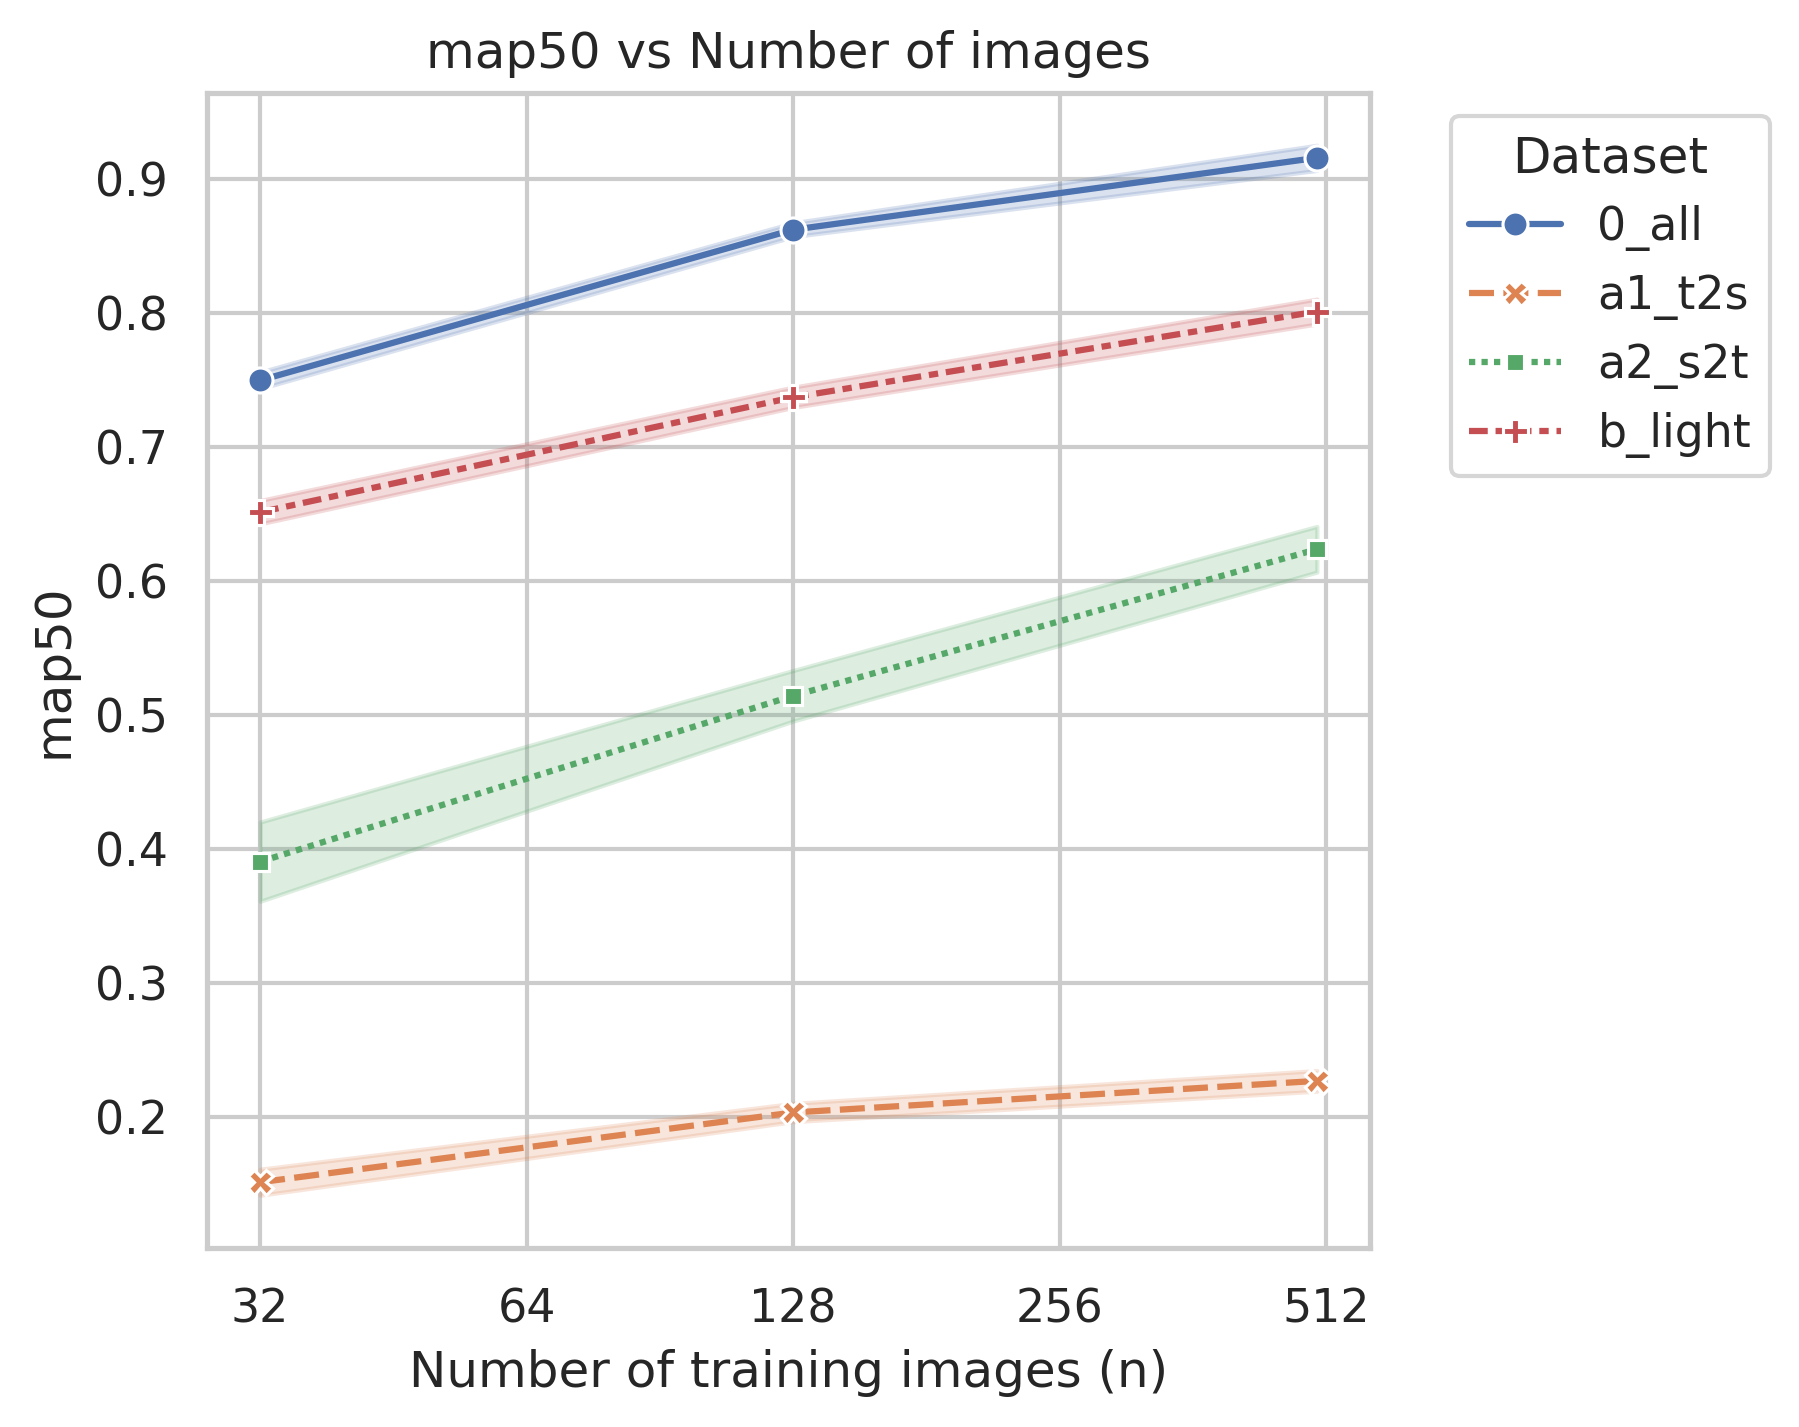

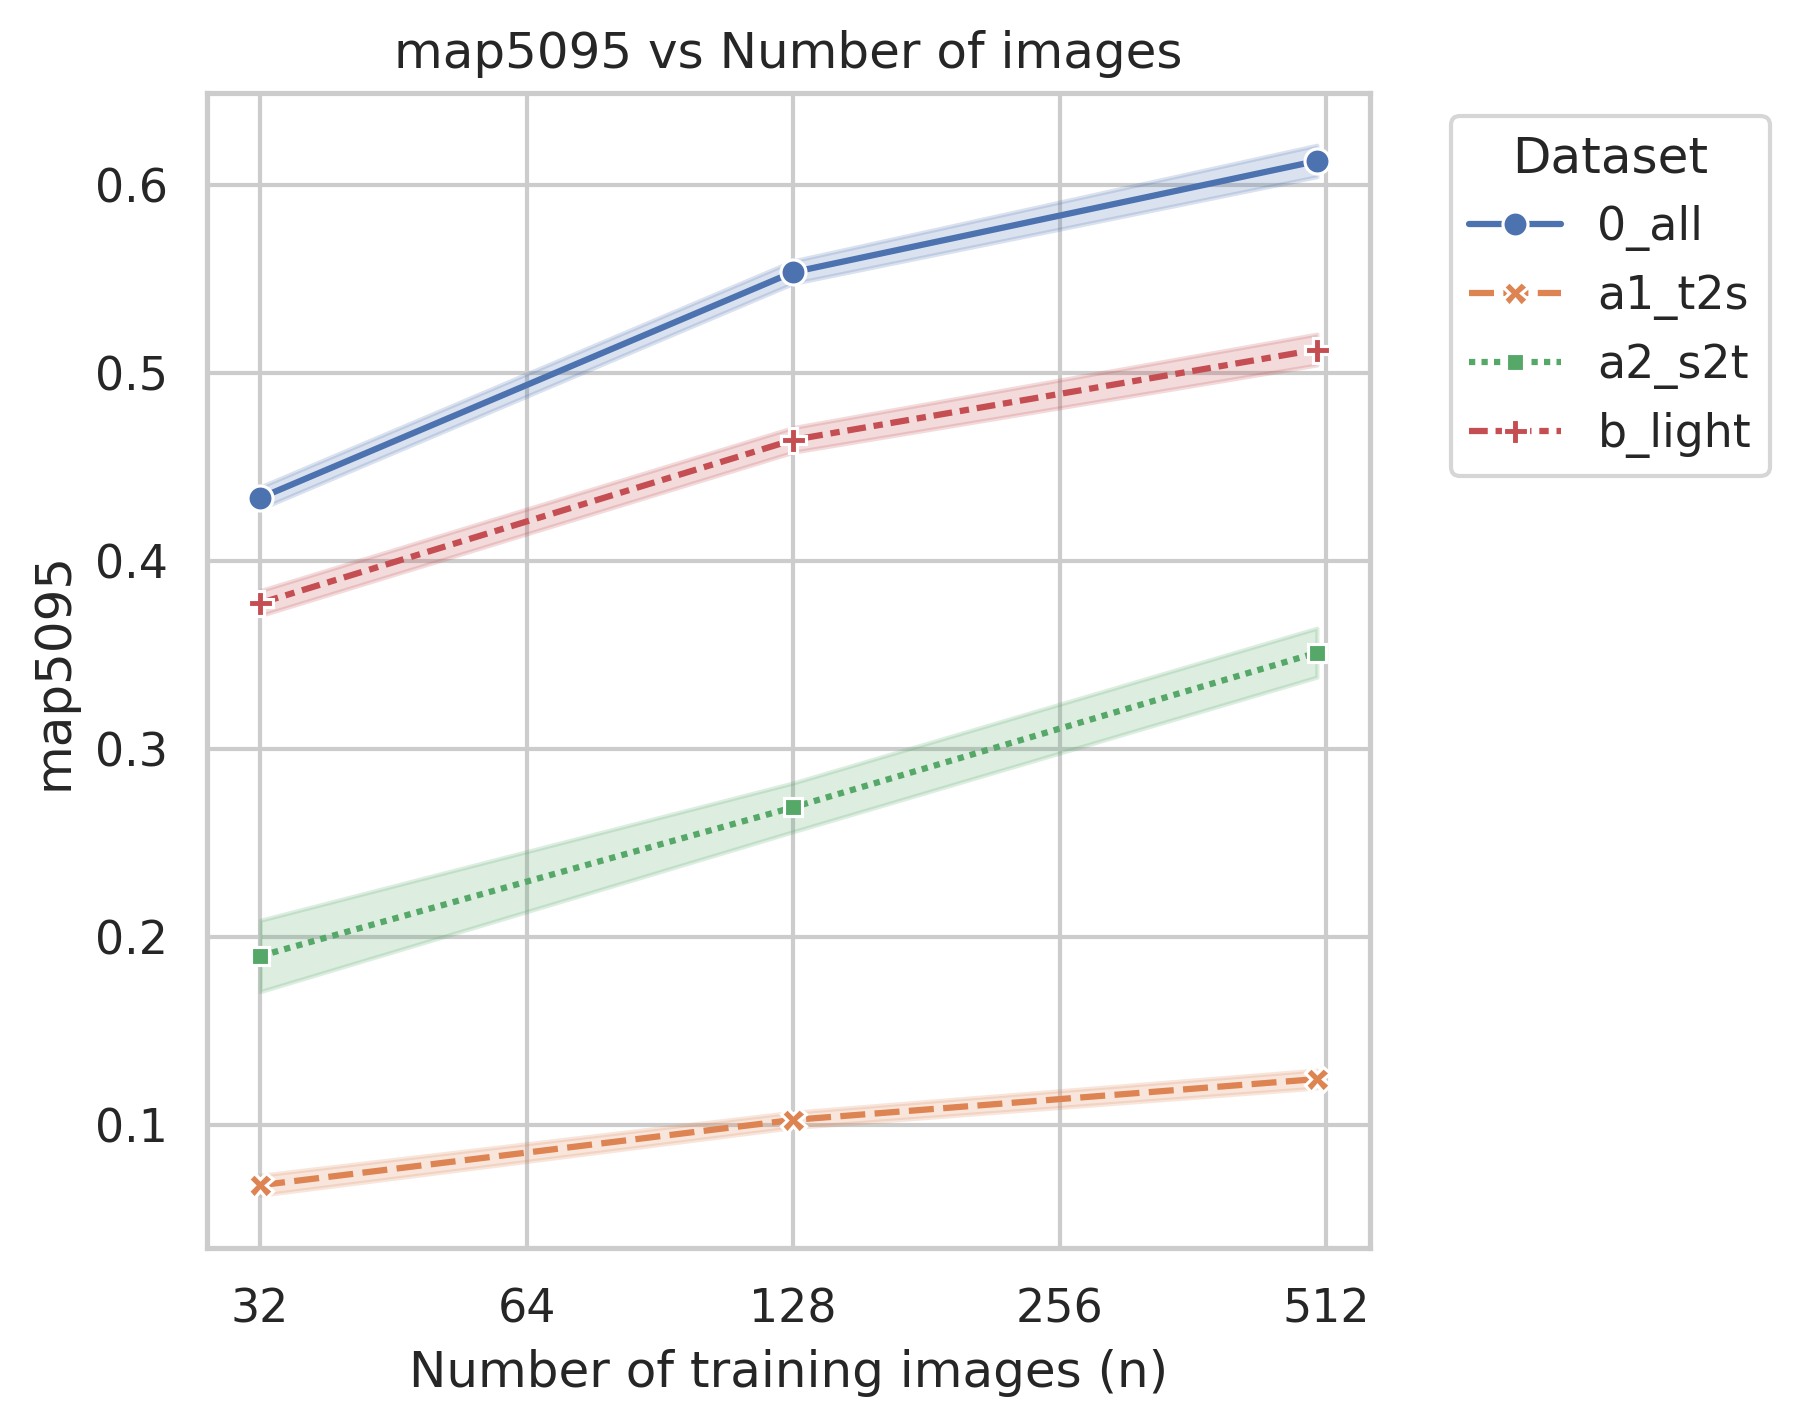

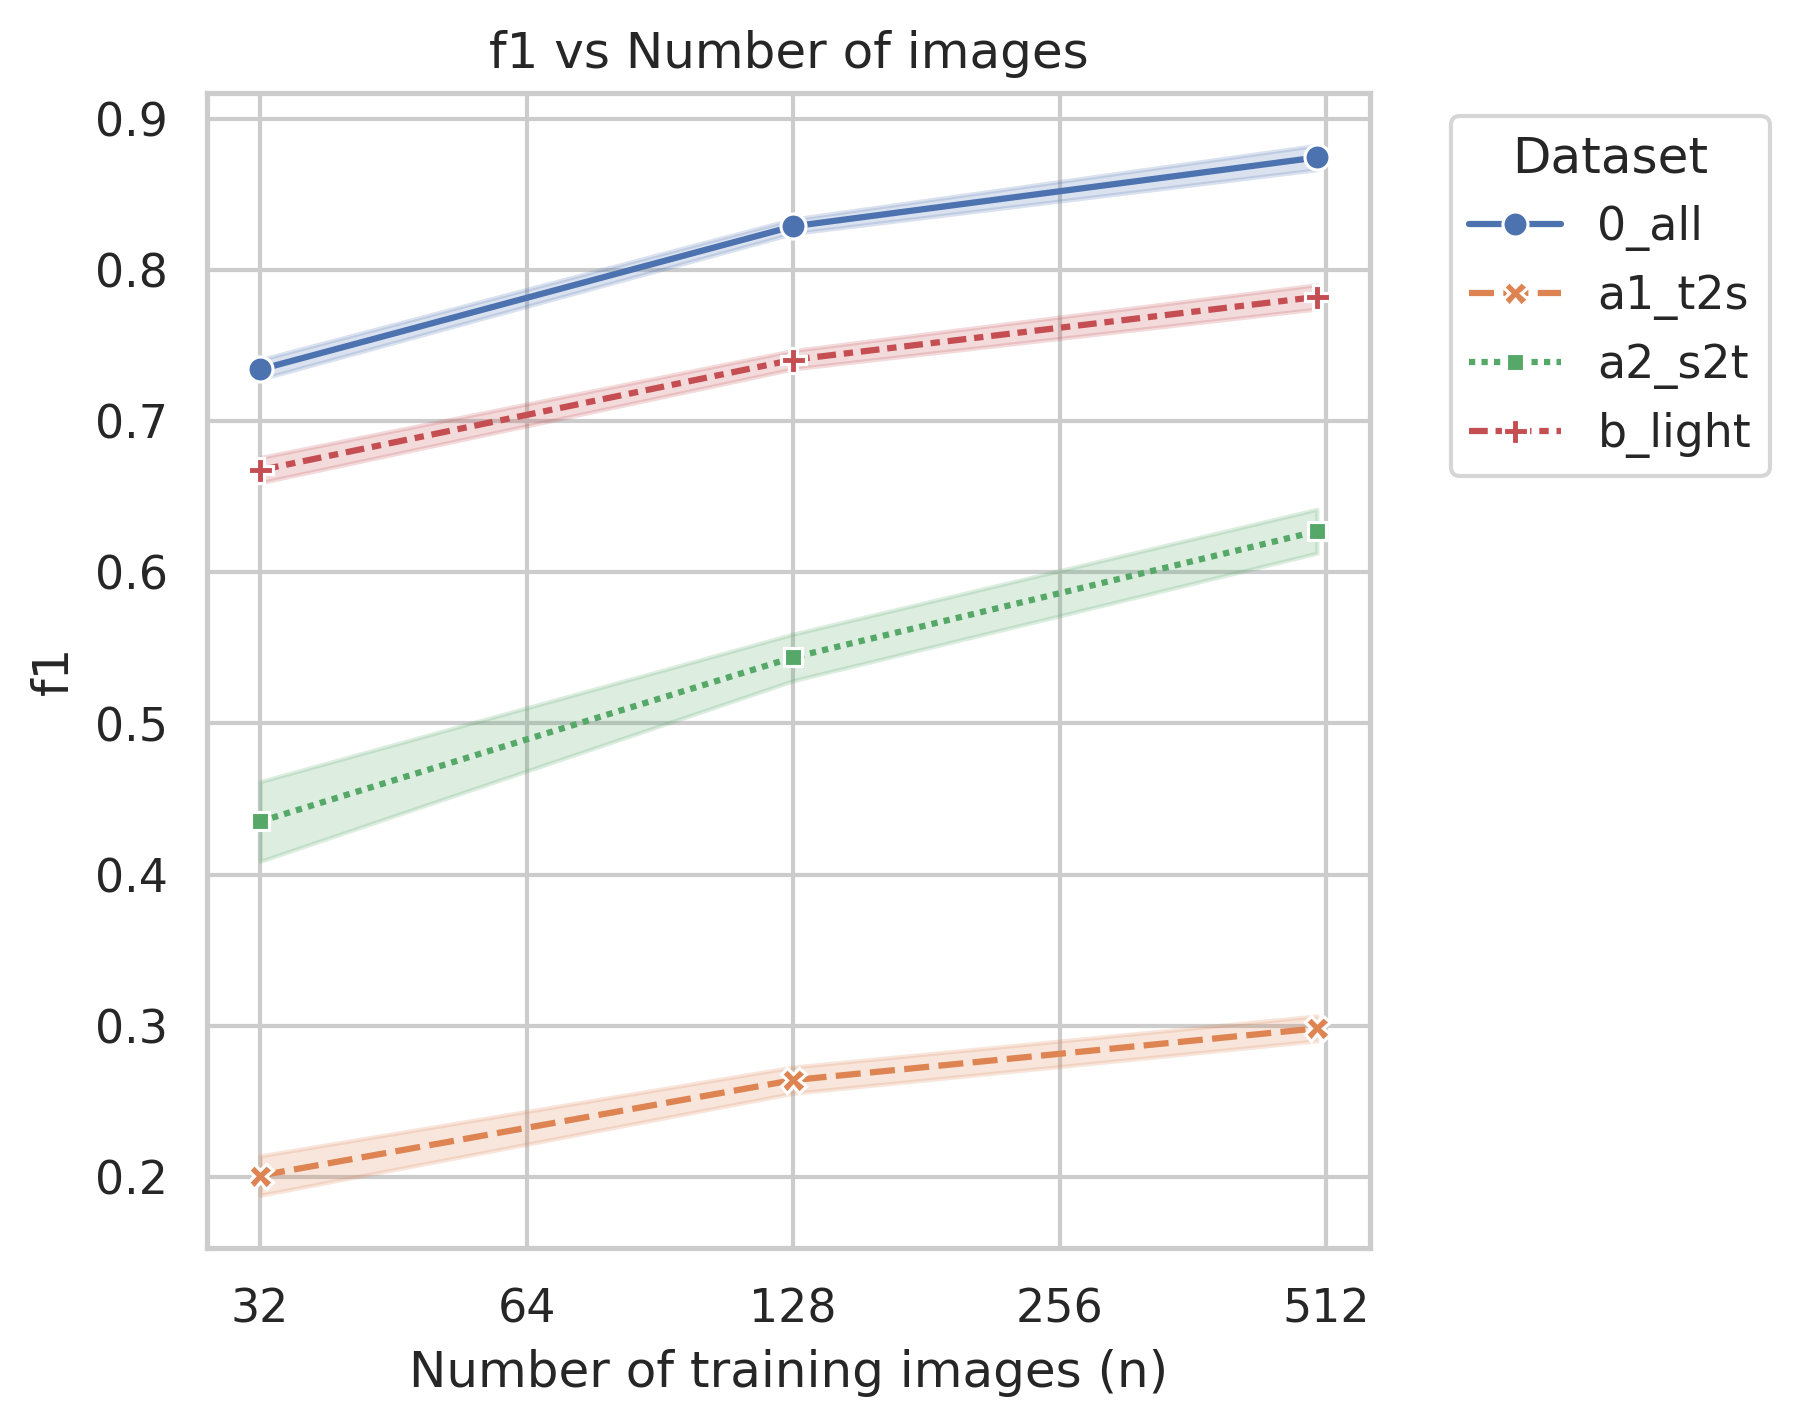

In [75]:
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
sns.set(style="whitegrid")
df_s1 = df_s1.query("n != 16 and n != 64")

def plot_s1_overview(df, metric):
    plt.figure(figsize=(5, 5), dpi=300)
    sns.lineplot(data=df_s1, x="n", y=metric, hue="data", style="data",
        hue_order=config_s1,
        style_order=config_s1,
        err_style="band", errorbar=("se", 2),
        markers=True,
        # palette=["Grey", "#00B000", "#009ADE", "#FF1F5B"],
        )
    plt.xscale("log")
    plt.xticks([2**i for i in range(5, 10)], [2**i for i in range(5, 10)])
    plt.xlabel("Number of training images (n)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Number of images")
    plt.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
plot_s1_overview(df_s1, "map50")
plot_s1_overview(df_s1, "map5095")
plot_s1_overview(df_s1, "f1")


Text(0.5, 0.98, 'mAP@0.5:0.95 vs Number of images')

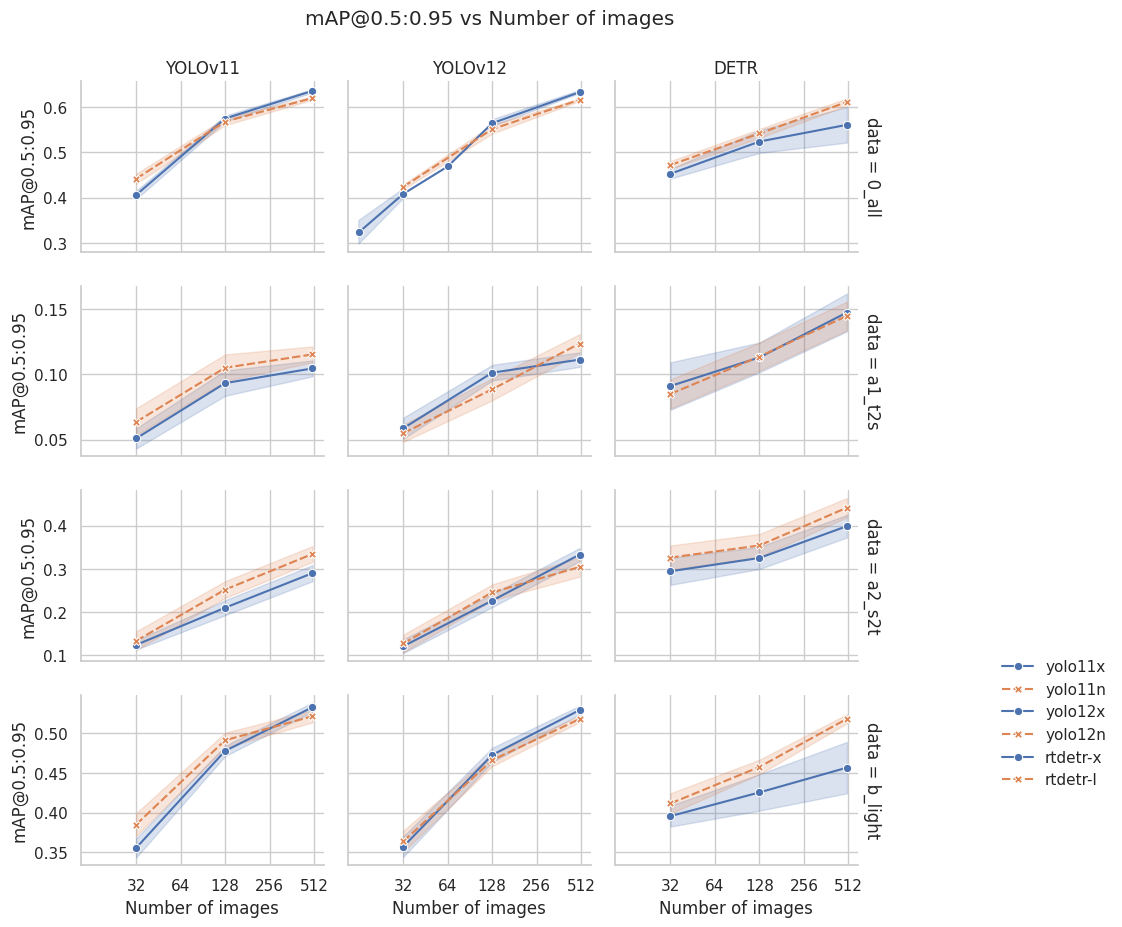

In [12]:
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
sns.set(style="whitegrid")
g = sns.FacetGrid(df_s1, 
    col="family", col_order=["YOLOv11", "YOLOv12", "DETR"],
    row="data", row_order=config_s1, sharey="row",
    margin_titles=True, height=6, aspect=1.2)
g.map_dataframe(sns.lineplot, 
    x="n", y="map5095", hue="model", style="model",
    # hue_order=config_s1,
    # style_order=config_s1,
    err_style="band", errorbar=("se", 2),
    markers=True,
    # palette=["Grey", "#00B000", "#009ADE", "#FF1F5B"],
    )
g.set(
    xscale="log",
    xticks=[2**i for i in range(5, 10)],
    xticklabels=[2**i for i in range(5, 10)],
    xlabel="Number of training images (n)",)

g.add_legend(bbox_to_anchor=(1.2, 0.1), loc='lower right')
g.set_axis_labels("Number of images", "mAP@0.5:0.95")
g.set_titles(col_template="{col_name}")
# g.set(ylim=(0, 0.65))
g.figure.set_size_inches(9, 9)
g.figure.subplots_adjust(top=0.9, hspace=0.2, wspace=0.1)
g.fig.suptitle("mAP@0.5:0.95 vs Number of images")

In [84]:
config_ext = ["e_IMU", "e_VT"]
df_s2 = df.query("data in @config_ext").loc[:, ["data", "model", "n", "map5095", "pretrain", "family"]]
df_s2

,data,model,n,map5095,pretrain,family
6842,e_VT,rtdetr-x,32,0.4961,False,DETR
6843,e_IMU,rtdetr-l,200,0.5500,True,DETR
6844,e_IMU,rtdetr-l,200,0.5280,False,DETR
6845,e_IMU,rtdetr-l,128,0.5220,True,DETR
6846,e_IMU,rtdetr-l,128,0.5096,False,DETR
...,...,...,...,...,...,...
18377,e_VT,yolo12x,64,0.5586,False,YOLOv12
18378,e_VT,yolo12x,32,0.0642,True,YOLOv12
18379,e_VT,yolo12x,32,0.5217,False,YOLOv12
18380,e_IMU,yolo11x,200,0.5012,True,YOLOv11


Text(0.5, 0.98, 'mAP@0.5:0.95 vs Number of images')

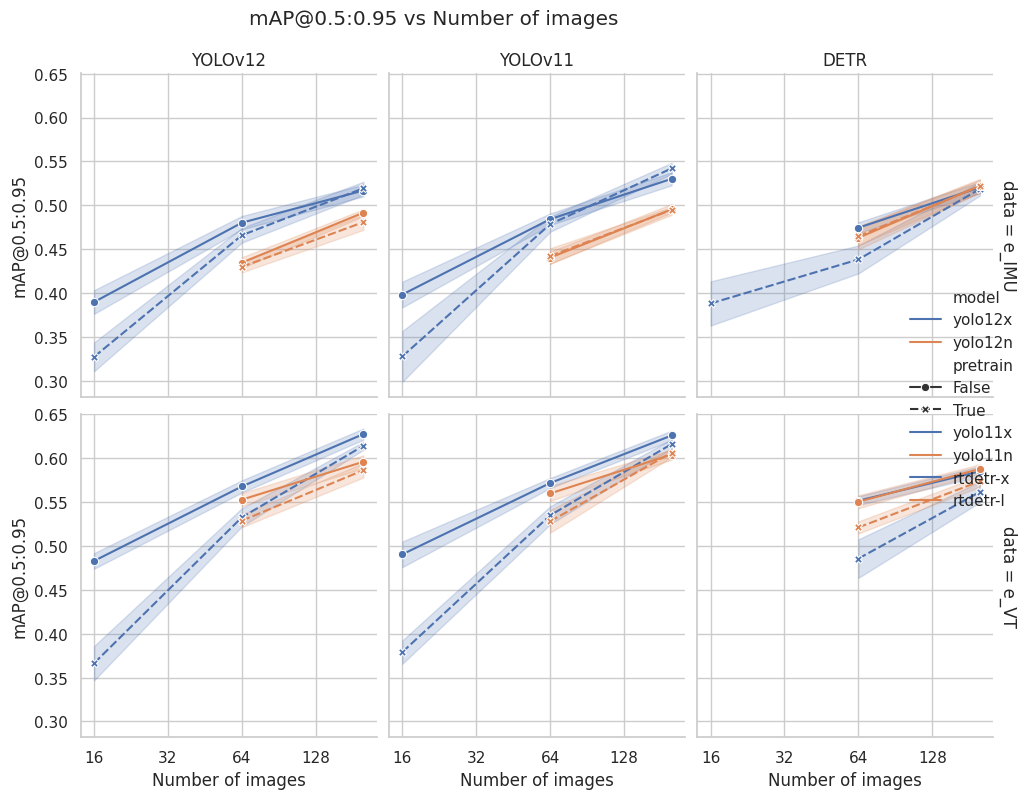

In [46]:
# facet by model
config_ext = ["e_IMU", "e_VT"]

g = sns.FacetGrid(df_s2, 
    row="data", col="family",
    col_order=["YOLOv12", "YOLOv11", "DETR"],
    margin_titles=True, height=5)
g.map_dataframe(sns.lineplot, 
    x="n", y="map5095", hue="model", style="pretrain",
     # style_order=["True", "False"],
    err_style="band", errorbar=("se", 2),
    markers=True,
    # palette=["#00B000", "#009ADE", "#FF1F5B"],
    )
# x-axis: 32, 64, 128, 256, 500, in log scale
g.set(
    xscale="log",
    xticks=[2**i for i in range(4, 8)],
    xticklabels=[2**i for i in range(4, 8)],
    xlabel="Number of training images (n)",)
g.add_legend()
g.set_axis_labels("Number of images", "mAP@0.5:0.95")
g.set_titles(col_template="{col_name}")
# g.set(ylim=(0, 0.95))
g.figure.set_size_inches(8, 8)
g.figure.subplots_adjust(right=1.2, top=0.9)
g.fig.suptitle("mAP@0.5:0.95 vs Number of images")